In [49]:
from pathlib import Path

import pandas as pd

from plot_bspoints import (
    build_bspoints_from_kline,
    plot_bspoints,
)


# ============================================================
# 1. GENERATE PRICE DATA AND BSP DATA
# ============================================================

data_path = Path("DataAPI/data/QQQ_5M.csv")

start_time = pd.Timestamp("2020-01-01")
end_time = pd.Timestamp("2026-05-30")

price_df, bsp_df = build_bspoints_from_kline(
    data_path,
    code="QQQ",
    freq="5m",
    start=start_time,
    end=end_time,
    max_klines=500,
    warmup_bars=500,
)


# ============================================================
# 2. VERIFY THE DATA
# ============================================================

print("price_df shape:", price_df.shape)
print("bsp_df shape:", bsp_df.shape)

print("\nprice_df columns:")
print(price_df.columns.tolist())

print("\nbsp_df columns:")
print(bsp_df.columns.tolist())

display(price_df.head())
display(bsp_df.head())

price_df shape: (305893, 12)
bsp_df shape: (39232, 66)

price_df columns:
['timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', '_open', '_high', '_low', '_close', '_vol', 'day']

bsp_df columns:
['klu_idx', 'timestamp', 'klu_open', 'klu_high', 'klu_low', 'klu_close', 'klu_volume', 'bsp_type', 'bsp_types', 'is_buy', 'direction', 'bi_direction', 'segment_direction', 'is_segbsp', 'feat_divergence_rate', 'feat_bsp1_bi_amp', 'feat_bsp1_bi_klu_cnt', 'feat_bsp1_bi_amp_rate', 'feat_zs_cnt', 'feat_ppo', 'feat_bsp_bi_amp', 'feat_break_bi_amp', 'feat_break_bi_klu_cnt', 'feat_break_bi_amp_rate', 'feat_bi_amp', 'feat_bi_klu_cnt', 'feat_bi_amp_rate', 'feat_level', 'feat_bsp_type', 'macd_value', 'macd_diff', 'macd_dea', 'rsi', 'kdj_k', 'kdj_d', 'kdj_j', 'dmi_plus', 'dmi_minus', 'dmi_adx', 'price_change_pct', 'high_low_spread_pct', 'upper_shadow', 'lower_shadow', 'body_size', 'is_bullish_candle', 'snapshot_first_seen', 'snapshot_last_seen', 'feat_bsp2_retrace_rate', 'feat_bsp2_break_bi_amp', 'feat_

,timestamp,Open,High,Low,Close,Volume,_open,_high,_low,_close,_vol,day
0,2020-01-02 04:00:00,213.98,214.06,213.95,214.06,16215,213.98,214.06,213.95,214.06,16215.0,2020-01-02
1,2020-01-02 04:05:00,214.03,214.18,214.03,214.13,2514,214.03,214.18,214.03,214.13,2514.0,2020-01-02
2,2020-01-02 04:10:00,214.13,214.18,214.13,214.18,1392,214.13,214.18,214.13,214.18,1392.0,2020-01-02
3,2020-01-02 04:15:00,214.18,214.20,214.14,214.20,18500,214.18,214.20,214.14,214.20,18500.0,2020-01-02
4,2020-01-02 04:20:00,214.17,214.18,214.15,214.18,1600,214.17,214.18,214.15,214.18,1600.0,2020-01-02


,klu_idx,timestamp,klu_open,klu_high,klu_low,klu_close,klu_volume,bsp_type,bsp_types,is_buy,...,feat_bsp2s_break_bi_klu_cnt,feat_bsp2s_break_bi_amp_rate,feat_bsp2s_bi_amp,feat_bsp2s_bi_klu_cnt,feat_bsp2s_bi_amp_rate,feat_bsp2s_lv,feat_bsp3_zs_height,feat_bsp3_bi_amp,feat_bsp3_bi_klu_cnt,feat_bsp3_bi_amp_rate
0,500,2020-01-02 04:00:00,213.98,214.06,213.95,214.06,16215.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,501,2020-01-02 04:05:00,214.03,214.18,214.03,214.13,2514.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,502,2020-01-02 04:10:00,214.13,214.18,214.13,214.18,1392.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,503,2020-01-02 04:15:00,214.18,214.20,214.14,214.20,18500.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,507,2020-01-02 04:40:00,214.18,214.23,214.08,214.11,2638.0,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
plot_output = Path("outputs/bspoints_QQQ_5m_2020-2026.png")
excel_output = Path("outputs/bspoints_QQQ_5m_2020-2026.xlsx")
plot_output.parent.mkdir(parents=True, exist_ok=True)
plot_bspoints(
    price_df,
    bsp_df,
    title="QQQ 5min BSP points",
    output=plot_output,
    annotate=False,  # Shows BSP type, buy/sell, Bi direction and segment direction
    show_volume=False,
)
bsp_df.to_excel(
    excel_output,
    sheet_name="BSP Points",
    index=False,
)

In [5]:
from pathlib import Path
import pandas as pd

data_path = Path("DataAPI/data/QQQ_5M.csv")
bsp_path = Path("outputs/bspoints_QQQ_5m_2020-2026.xlsx")


# ============================================================
# 1. LOAD PRICE DATA
# ============================================================

price_df = pd.read_csv(data_path)

print("Original price columns:", price_df.columns.tolist())

# Normalize common column-name variants
price_df.rename(
    columns={
        "Datetime": "timestamp",
        "DateTime": "timestamp",
        "datetime": "timestamp",
        "Date": "timestamp",
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    },
    inplace=True,
)

required_price_columns = {
    "timestamp",
    "open",
    "close",
}

missing_price_columns = (
    required_price_columns - set(price_df.columns)
)

if missing_price_columns:
    raise KeyError(
        "Price CSV is missing required columns: "
        f"{sorted(missing_price_columns)}. "
        f"Available columns: {price_df.columns.tolist()}"
    )

price_df["timestamp"] = pd.to_datetime(
    price_df["timestamp"],
    errors="raise",
)

for column in ["open", "high", "low", "close", "volume"]:
    if column in price_df.columns:
        price_df[column] = pd.to_numeric(
            price_df[column],
            errors="coerce",
        )

price_df.dropna(
    subset=["timestamp", "open", "close"],
    inplace=True,
)

price_df.sort_values("timestamp", inplace=True)

price_df.drop_duplicates(
    subset=["timestamp"],
    keep="last",
    inplace=True,
)

price_df.reset_index(drop=True, inplace=True)


# ============================================================
# 2. LOAD SAVED BSP POINTS
# ============================================================

bsp_df = pd.read_excel(
    bsp_path,
    sheet_name="BSP Points",
    engine="openpyxl",
)

required_bsp_columns = {
    "timestamp",
    "direction",
    "bsp_type",
}

missing_bsp_columns = required_bsp_columns - set(bsp_df.columns)

if missing_bsp_columns:
    raise KeyError(
        "BSP workbook is missing required columns: "
        f"{sorted(missing_bsp_columns)}"
    )

bsp_df["timestamp"] = pd.to_datetime(
    bsp_df["timestamp"],
    errors="raise",
)

bsp_df.sort_values("timestamp", inplace=True)
bsp_df.reset_index(drop=True, inplace=True)


# ============================================================
# 3. ALIGN THE SIMULATION PERIOD
# ============================================================

start_timestamp = bsp_df["timestamp"].min()
end_timestamp = bsp_df["timestamp"].max()

price_df = price_df.loc[
    price_df["timestamp"].between(
        start_timestamp,
        end_timestamp,
        inclusive="both",
    )
].copy()

price_df.reset_index(drop=True, inplace=True)


# ============================================================
# 4. VALIDATE TIMESTAMP ALIGNMENT
# ============================================================

price_timestamps = set(price_df["timestamp"])

unmatched_bsp = bsp_df.loc[
    ~bsp_df["timestamp"].isin(price_timestamps)
].copy()

print(f"Price rows: {len(price_df):,}")
print(f"BSP rows: {len(bsp_df):,}")
print(f"Unmatched BSP rows: {len(unmatched_bsp):,}")
print(
    "Price period:",
    price_df["timestamp"].min(),
    "to",
    price_df["timestamp"].max(),
)
print(
    "BSP period:",
    bsp_df["timestamp"].min(),
    "to",
    bsp_df["timestamp"].max(),
)

Original price columns: ['timestamp', 'Open', 'High', 'Low', 'Close', 'Volume']
Price rows: 305,887
BSP rows: 39,232
Unmatched BSP rows: 0
Price period: 2020-01-02 04:00:00 to 2026-05-29 19:25:00
BSP period: 2020-01-02 04:00:00 to 2026-05-29 19:25:00


In [52]:
import pandas as pd
from pathlib import Path
SPY_RESULT = "outputs/strategy_backtest/SPY_5m_strategy_result.xlsx"

# Load BSP points
spy_bsp_df = pd.read_excel(
    SPY_RESULT,
    sheet_name="BSP Points",
    engine="openpyxl",
)

spy_bsp_df["timestamp"] = pd.to_datetime(
    spy_bsp_df["timestamp"],
    errors="raise",
)

spy_bsp_df.sort_values("timestamp", inplace=True)

spy_bsp_df.drop_duplicates(
    subset=["timestamp", "direction", "bsp_type"],
    keep="first",
    inplace=True,
)

spy_bsp_df.reset_index(drop=True, inplace=True)


# Load price data
spy_price_df = pd.read_excel(
    SPY_RESULT,
    sheet_name="Price Data",
    engine="openpyxl",
)

spy_price_df["timestamp"] = pd.to_datetime(
    spy_price_df["timestamp"],
    errors="raise",
)

spy_price_df.sort_values("timestamp", inplace=True)

# Ensure one price row per timestamp
spy_price_df.drop_duplicates(
    subset=["timestamp"],
    keep="last",
    inplace=True,
)

spy_price_df.reset_index(drop=True, inplace=True)


KeyboardInterrupt: 

In [54]:
import pandas as pd
from pathlib import Path
QQQ_RESULT = "outputs/strategy_backtest/QQQ_5m_strategy_result.xlsx"


qqq_bsp_df = pd.read_excel(
    QQQ_RESULT,
    sheet_name="BSP Points",
    engine="openpyxl",
)

qqq_bsp_df["timestamp"] = pd.to_datetime(
    qqq_bsp_df["timestamp"],
    errors="raise",
)

qqq_bsp_df.sort_values("timestamp", inplace=True)

qqq_bsp_df.drop_duplicates(
    subset=["timestamp", "direction", "bsp_type"],
    keep="first",
    inplace=True,
)

qqq_bsp_df.reset_index(drop=True, inplace=True)


# Load price data
qqq_price_df = pd.read_excel(
    QQQ_RESULT,
    sheet_name="Price Data",
    engine="openpyxl",
)

qqq_price_df["timestamp"] = pd.to_datetime(
    qqq_price_df["timestamp"],
    errors="raise",
)

qqq_price_df.sort_values("timestamp", inplace=True)

# Ensure one price row per timestamp
qqq_price_df.drop_duplicates(
    subset=["timestamp"],
    keep="last",
    inplace=True,
)

qqq_price_df.reset_index(drop=True, inplace=True)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/strategy_backtest/QQQ_5m_strategy_result.xlsx'

In [53]:
import pandas as pd
from pathlib import Path
TQQQ_RESULT = "outputs/strategy_backtest/TQQQ_5m_strategy_result.xlsx"


tqqq_bsp_df = pd.read_excel(
    TQQQ_RESULT,
    sheet_name="BSP Points",
    engine="openpyxl",
)

tqqq_bsp_df["timestamp"] = pd.to_datetime(
    tqqq_bsp_df["timestamp"],
    errors="raise",
)

tqqq_bsp_df.sort_values("timestamp", inplace=True)

tqqq_bsp_df.drop_duplicates(
    subset=["timestamp", "direction", "bsp_type"],
    keep="first",
    inplace=True,
)

tqqq_bsp_df.reset_index(drop=True, inplace=True)


# Load price data
tqqq_price_df = pd.read_excel(
    TQQQ_RESULT,
    sheet_name="Price Data",
    engine="openpyxl",
)

tqqq_price_df["timestamp"] = pd.to_datetime(
    tqqq_price_df["timestamp"],
    errors="raise",
)

tqqq_price_df.sort_values("timestamp", inplace=True)

# Ensure one price row per timestamp
tqqq_price_df.drop_duplicates(
    subset=["timestamp"],
    keep="last",
    inplace=True,
)

tqqq_price_df.reset_index(drop=True, inplace=True)

KeyboardInterrupt: 

In [6]:
# ============================================================
# 3. NORMALIZE PRICE COLUMNS
# ============================================================

price_df = price_df.copy()

column_mapping = {}

if "open" not in price_df.columns and "_open" in price_df.columns:
    column_mapping["_open"] = "open"

if "high" not in price_df.columns and "_high" in price_df.columns:
    column_mapping["_high"] = "high"

if "low" not in price_df.columns and "_low" in price_df.columns:
    column_mapping["_low"] = "low"

if "close" not in price_df.columns and "_close" in price_df.columns:
    column_mapping["_close"] = "close"

if column_mapping:
    price_df = price_df.rename(
        columns=column_mapping
    )

required_price_columns = {
    "timestamp",
    "open",
    "close",
}

missing_price_columns = (
    required_price_columns
    - set(price_df.columns)
)

if missing_price_columns:
    raise KeyError(
        "price_df is missing required columns: "
        f"{sorted(missing_price_columns)}"
    )

required_bsp_columns = {
    "timestamp",
    "direction",
    "bsp_type",
}

missing_bsp_columns = (
    required_bsp_columns
    - set(bsp_df.columns)
)

if missing_bsp_columns:
    raise KeyError(
        "bsp_df is missing required columns: "
        f"{sorted(missing_bsp_columns)}"
    )

price_df["timestamp"] = pd.to_datetime(
    price_df["timestamp"]
)

bsp_df["timestamp"] = pd.to_datetime(
    bsp_df["timestamp"]
)

print("Data is ready for backtesting.")

Data is ready for backtesting.


In [32]:
from CustomBuySellPoint import (
    SegBspStrategy,
    SegBspStrategyConfig,
)
from ModelStrategy import (
    BacktestChanConfig,
    run_bsp_backtest,
)
from Trade import RiskConfig, RiskManager


# ============================================================
# 4. CREATE STRATEGY
# ============================================================

strategy = SegBspStrategy(
    SegBspStrategyConfig(
        # Allow entries in both segment directions.
        entry_segment_directions=frozenset({
            "up",
            "down",
        }),

        entry_bsp_types=frozenset({
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        }),

        sell_bsp_types=frozenset({
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        }),

        # ====================================================
        # BUY LOOKBACK FOR EACH SEGMENT
        # ====================================================

        buy_lookback_bars_by_segment={
            "up": 10,
            "down": 15,
        },

        # ====================================================
        # REQUIRED BUY SIGNALS FOR EACH SEGMENT AND BSP TYPE
        # ====================================================

        required_buy_signals_by_segment={
            # Trend-following entry.
            "up": {
                "1": 1,
                "1p": 1,
                "2": 1,
                "2s": 1,
                "3a": 1,
                "3b": 1,
            },

            # Contrarian entry requires stronger confirmation.
            "down": {
                "1": 5,
                "1p": 10,
                "2": 5,
                "2s": 5,
                "3a": 10,
                "3b": 10,
            },
        },

        # ====================================================
        # SELL LOOKBACK BASED ON ENTRY SEGMENT
        # ====================================================

        sell_lookback_bars_by_entry_segment={
            "up": 20,
            "down": 10,
        },

        # ====================================================
        # REQUIRED SELL SIGNALS BASED ON ENTRY SEGMENT
        # ====================================================

        required_sell_signals_by_entry_segment={
            # Position originally opened in an up segment.
            "up": {
                "1": 15,
                "1p": 15,
                "2": 15,
                "2s": 15,
                "3a": 15,
                "3b": 15,
            },

            # Position originally opened in a down segment.
            # Exit more quickly if the reversal fails.
            "down": {
                "1": 1,
                "1p": 1,
                "2": 1,
                "2s": 1,
                "3a": 1,
                "3b": 1,
            },
        },

        # ====================================================
        # STRUCTURAL EXIT
        # ====================================================

        exit_segment_directions_by_entry_segment={
            # Up-segment entry exits if structure turns down.
            "up": frozenset({
                "down",
            }),

            # Down-segment entry is allowed to remain open
            # while the segment is still down.
            "down": frozenset(),
        },

        # Global fallback values.
        required_buy_signals=1,
        buy_lookback_bars=15,
        required_sell_signals=5,
        sell_lookback_bars=10,

        exit_on_down_segment=True,
        allow_unconfirmed_entry=False,
        reset_sell_count_on_buy=True,
        reset_buy_count_on_sell=True,
        position_fraction=1.0,
    )
)

# ============================================================
# 5. RISK MANAGEMENT
# ============================================================

risk_manager = RiskManager(
    RiskConfig(
        stop_loss_pct=0.025,
        take_profit_pct=0.10,
        trailing_stop_pct=0.025,
        max_holding_bars=78 * 10,
    )
)


# ============================================================
# 6. BACKTEST CONFIGURATION
# ============================================================

backtest_config = BacktestChanConfig(
    initial_capital=100_000,
    fee_pct=0.000,
    slippage_pct=0.000,
    close_at_end=True,
)


# ============================================================
# 7. RUN BACKTEST
# ============================================================

result = run_bsp_backtest(
    price_df=price_df,
    bsp_df=bsp_df,
    strategy=strategy,
    config=backtest_config,
    risk_manager=risk_manager,
)


# ============================================================
# 8. DISPLAY RESULTS
# ============================================================

print("\nStrategy metrics:")

for name, value in result.metrics.items():
    print(f"{name}: {value}")

print("\nTrade count:", len(result.trades))

display(result.trades)
display(result.equity.tail())


Strategy metrics:
final_equity: 733374.6830259975
total_return: 6.333746830259975
max_drawdown: -0.13505492852623135
sharpe: 1.5075451637101298
closed_trades: 755
win_rate: 0.6410596026490066
profit_factor: 1.9226565492385645

Trade count: 1510


,side,seen_idx,exec_idx,exec_px,reason,position_fraction,idx,px,raw_px,qty,fee,pnl,return_pct
0,buy,625,626,215.140,5/5 type-1 buy-signal bars in 15-bar window; B...,1.0,626,215.140,215.140,464.813610,0.0,NaN,NaN
1,sell,645,646,216.050,1/1 type-2 sell-signal bars in 10-bar window i...,1.0,646,216.050,216.050,464.813610,0.0,422.980385,0.004230
2,buy,732,733,212.560,5/5 type-1 buy-signal bars in 15-bar window; B...,1.0,733,212.560,212.560,472.445335,0.0,NaN,NaN
3,sell,777,778,215.830,1/1 type-2s sell-signal bars in 10-bar window ...,1.0,778,215.830,215.830,472.445335,0.0,1544.896245,0.015384
4,buy,2325,2326,222.965,1/1 type-2 buy-signal bars in 10-bar window; B...,1.0,2326,222.965,222.965,457.326830,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1505,sell,303760,303761,716.500,1/1 type-1 sell-signal bars in 10-bar window i...,1.0,303761,716.500,716.500,1009.914930,0.0,13199.588133,0.018580
1506,buy,304115,304116,709.000,5/5 type-2s buy-signal bars in 15-bar window; ...,1.0,304116,709.000,709.000,1020.598092,0.0,NaN,NaN
1507,sell,304571,304572,706.740,1/1 type-1p sell-signal bars in 10-bar window ...,1.0,304572,706.740,706.740,1020.598092,0.0,-2306.551688,-0.003188
1508,buy,304594,304595,705.340,1/1 type-2s buy-signal bars in 10-bar window; ...,1.0,304595,705.340,705.340,1022.623835,0.0,NaN,NaN


,timestamp,bar_index,equity,position
305882,2026-05-29 19:05:00,305882,733374.683026,0
305883,2026-05-29 19:10:00,305883,733374.683026,0
305884,2026-05-29 19:15:00,305884,733374.683026,0
305885,2026-05-29 19:20:00,305885,733374.683026,0
305886,2026-05-29 19:25:00,305886,733374.683026,0


In [28]:
# ============================================================
# 9. SAVE COMPLETE RESULT TO EXCEL
# ============================================================

from dataclasses import asdict
from pathlib import Path
import json

import pandas as pd


# ------------------------------------------------------------
# OUTPUT PATH
# ------------------------------------------------------------

output_dir = Path(
    "outputs/strategy_backtest"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

excel_output = (
    output_dir
    / "qqq_5m_strategy_result.xlsx"
)


# ------------------------------------------------------------
# METRICS SHEET
# ------------------------------------------------------------

metrics_df = pd.DataFrame(
    [
        {
            "metric": metric_name,
            "value": metric_value,
        }
        for metric_name, metric_value
        in result.metrics.items()
    ]
)


# ------------------------------------------------------------
# TRADE/FILL SHEET
# ------------------------------------------------------------

trades_df = result.trades.copy()

if not trades_df.empty:
    # Determine which column contains the execution bar index.
    if "idx" in trades_df.columns:
        execution_index_column = "idx"

    elif "exec_idx" in trades_df.columns:
        execution_index_column = "exec_idx"

    else:
        execution_index_column = None

    # Add execution timestamps using price_df.
    if execution_index_column is not None:

        def get_execution_timestamp(value):
            if pd.isna(value):
                return pd.NaT

            index = int(value)

            if (
                index < 0
                or index >= len(price_df)
            ):
                return pd.NaT

            return pd.to_datetime(
                price_df.iloc[index]["timestamp"]
            )

        trades_df[
            "execution_timestamp"
        ] = trades_df[
            execution_index_column
        ].map(
            get_execution_timestamp
        )

    # Add the signal-discovery timestamp.
    if "seen_idx" in trades_df.columns:

        def get_signal_timestamp(value):
            if pd.isna(value):
                return pd.NaT

            index = int(value)

            if (
                index < 0
                or index >= len(price_df)
            ):
                return pd.NaT

            return pd.to_datetime(
                price_df.iloc[index]["timestamp"]
            )

        trades_df[
            "signal_timestamp"
        ] = trades_df[
            "seen_idx"
        ].map(
            get_signal_timestamp
        )

    # Put the important columns first.
    preferred_trade_columns = [
        "side",
        "signal_timestamp",
        "execution_timestamp",
        "seen_idx",
        "exec_idx",
        "idx",
        "raw_px",
        "px",
        "qty",
        "fee",
        "reason",
        "pnl",
        "return_pct",
    ]

    ordered_trade_columns = [
        column
        for column in preferred_trade_columns
        if column in trades_df.columns
    ]

    remaining_trade_columns = [
        column
        for column in trades_df.columns
        if column not in ordered_trade_columns
    ]

    trades_df = trades_df[
        ordered_trade_columns
        + remaining_trade_columns
    ]


# ------------------------------------------------------------
# COMPLETED TRADES SHEET
# ------------------------------------------------------------

completed_trades_rows = []

if not trades_df.empty:
    current_buy = None

    for _, trade in trades_df.iterrows():
        side = str(
            trade.get("side", "")
        ).lower()

        if side == "buy":
            current_buy = trade

        elif (
            side == "sell"
            and current_buy is not None
        ):
            entry_price = float(
                current_buy.get(
                    "px",
                    current_buy.get(
                        "raw_px",
                        float("nan"),
                    ),
                )
            )

            exit_price = float(
                trade.get(
                    "px",
                    trade.get(
                        "raw_px",
                        float("nan"),
                    ),
                )
            )

            quantity = float(
                trade.get(
                    "qty",
                    current_buy.get(
                        "qty",
                        0.0,
                    ),
                )
            )

            entry_fee = float(
                current_buy.get(
                    "fee",
                    0.0,
                )
            )

            exit_fee = float(
                trade.get(
                    "fee",
                    0.0,
                )
            )

            gross_pnl = (
                exit_price
                - entry_price
            ) * quantity

            net_pnl = (
                gross_pnl
                - entry_fee
                - exit_fee
            )

            return_pct = (
                exit_price
                / entry_price
                - 1.0
                if entry_price != 0
                else float("nan")
            )

            entry_timestamp = current_buy.get(
                "execution_timestamp",
                pd.NaT,
            )

            exit_timestamp = trade.get(
                "execution_timestamp",
                pd.NaT,
            )

            if (
                pd.notna(entry_timestamp)
                and pd.notna(exit_timestamp)
            ):
                holding_minutes = (
                    pd.to_datetime(
                        exit_timestamp
                    )
                    - pd.to_datetime(
                        entry_timestamp
                    )
                ).total_seconds() / 60.0

            else:
                holding_minutes = float("nan")

            completed_trades_rows.append(
                {
                    "entry_signal_timestamp":
                        current_buy.get(
                            "signal_timestamp",
                            pd.NaT,
                        ),

                    "entry_timestamp":
                        entry_timestamp,

                    "exit_signal_timestamp":
                        trade.get(
                            "signal_timestamp",
                            pd.NaT,
                        ),

                    "exit_timestamp":
                        exit_timestamp,

                    "entry_price":
                        entry_price,

                    "exit_price":
                        exit_price,

                    "quantity":
                        quantity,

                    "entry_fee":
                        entry_fee,

                    "exit_fee":
                        exit_fee,

                    "total_fees":
                        entry_fee + exit_fee,

                    "gross_pnl":
                        gross_pnl,

                    "net_pnl":
                        net_pnl,

                    "return_pct":
                        return_pct,

                    "holding_minutes":
                        holding_minutes,

                    "entry_reason":
                        current_buy.get(
                            "reason",
                            "",
                        ),

                    "exit_reason":
                        trade.get(
                            "reason",
                            "",
                        ),
                }
            )

            current_buy = None

completed_trades_df = pd.DataFrame(
    completed_trades_rows
)


# ------------------------------------------------------------
# EXIT-REASON SUMMARY
# ------------------------------------------------------------

if (
    not trades_df.empty
    and "side" in trades_df.columns
    and "reason" in trades_df.columns
):
    exit_reason_df = (
        trades_df.loc[
            trades_df["side"].eq("sell"),
            "reason",
        ]
        .value_counts(
            dropna=False
        )
        .rename_axis(
            "exit_reason"
        )
        .reset_index(
            name="count"
        )
    )

else:
    exit_reason_df = pd.DataFrame(
        columns=[
            "exit_reason",
            "count",
        ]
    )


# ------------------------------------------------------------
# EQUITY SHEET
# ------------------------------------------------------------

equity_df = result.equity.copy()

if not equity_df.empty:
    equity_df["timestamp"] = pd.to_datetime(
        equity_df["timestamp"]
    )

    equity_df = equity_df.sort_values(
        "timestamp"
    ).reset_index(drop=True)

    equity_df["equity_return_pct"] = (
        equity_df["equity"]
        / float(
            backtest_config.initial_capital
        )
        - 1.0
    )

    equity_df["running_max_equity"] = (
        equity_df["equity"].cummax()
    )

    equity_df["drawdown_pct"] = (
        equity_df["equity"]
        / equity_df["running_max_equity"]
        - 1.0
    )


# ------------------------------------------------------------
# PRICE DATA SHEET
# ------------------------------------------------------------

price_export_df = price_df.copy()

if "timestamp" in price_export_df.columns:
    price_export_df["timestamp"] = (
        pd.to_datetime(
            price_export_df["timestamp"]
        )
    )


# ------------------------------------------------------------
# BSP POINTS SHEET
# ------------------------------------------------------------

bsp_export_df = bsp_df.copy()

if "timestamp" in bsp_export_df.columns:
    bsp_export_df["timestamp"] = (
        pd.to_datetime(
            bsp_export_df["timestamp"]
        )
    )


# ------------------------------------------------------------
# STRATEGY CONFIGURATION SHEET
# ------------------------------------------------------------

strategy_config_dict = asdict(
    strategy.config
)

strategy_config_rows = []

for config_name, config_value in (
    strategy_config_dict.items()
):
    if isinstance(
        config_value,
        (
            dict,
            list,
            tuple,
            set,
            frozenset,
        ),
    ):
        serializable_value = json.dumps(
            config_value,
            ensure_ascii=False,
            default=lambda value: (
                sorted(value)
                if isinstance(
                    value,
                    (
                        set,
                        frozenset,
                    ),
                )
                else str(value)
            ),
        )

    else:
        serializable_value = config_value

    strategy_config_rows.append(
        {
            "parameter": config_name,
            "value": serializable_value,
        }
    )

strategy_config_df = pd.DataFrame(
    strategy_config_rows
)


# ------------------------------------------------------------
# RISK CONFIGURATION SHEET
# ------------------------------------------------------------

risk_config_df = pd.DataFrame(
    [
        {
            "parameter": name,
            "value": value,
        }
        for name, value
        in asdict(
            risk_manager.config
        ).items()
    ]
)


# ------------------------------------------------------------
# BACKTEST CONFIGURATION SHEET
# ------------------------------------------------------------

backtest_config_df = pd.DataFrame(
    [
        {
            "parameter": name,
            "value": value,
        }
        for name, value
        in asdict(
            backtest_config
        ).items()
    ]
)


# ------------------------------------------------------------
# WRITE ONE EXCEL WORKBOOK
# ------------------------------------------------------------

with pd.ExcelWriter(
    excel_output,
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="Metrics",
        index=False,
    )

    trades_df.to_excel(
        writer,
        sheet_name="Fills",
        index=False,
    )

    completed_trades_df.to_excel(
        writer,
        sheet_name="Completed Trades",
        index=False,
    )

    exit_reason_df.to_excel(
        writer,
        sheet_name="Exit Reasons",
        index=False,
    )

    equity_df.to_excel(
        writer,
        sheet_name="Equity",
        index=False,
    )

    bsp_export_df.to_excel(
        writer,
        sheet_name="BSP Points",
        index=False,
    )

    price_export_df.to_excel(
        writer,
        sheet_name="Price Data",
        index=False,
    )

    strategy_config_df.to_excel(
        writer,
        sheet_name="Strategy Config",
        index=False,
    )

    risk_config_df.to_excel(
        writer,
        sheet_name="Risk Config",
        index=False,
    )

    backtest_config_df.to_excel(
        writer,
        sheet_name="Backtest Config",
        index=False,
    )


print(
    "Excel result saved:"
)

print(
    excel_output.resolve()
)

Excel result saved:
C:\Users\TonyTang\Documents\chan.py\outputs\strategy_backtest\qqq_5m_strategy_result.xlsx


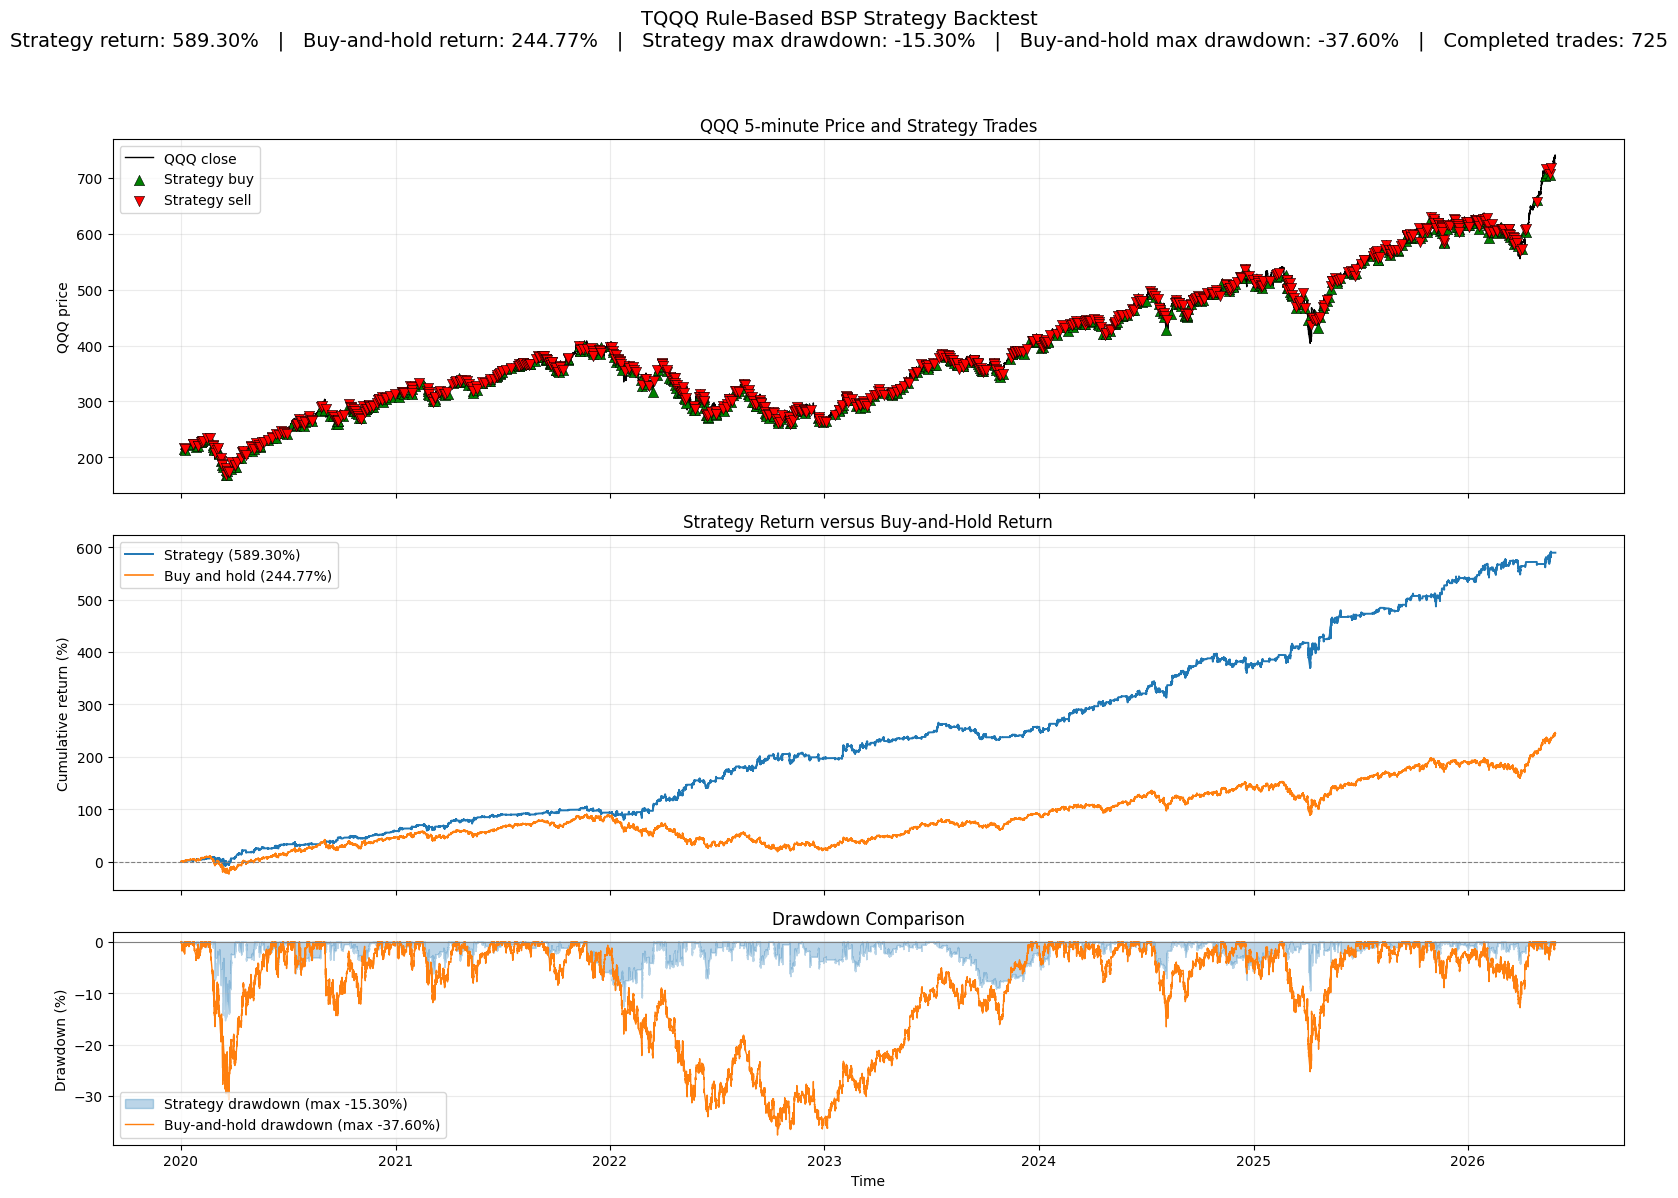

Comparison plot saved: C:\Users\TonyTang\Documents\chan.py\outputs\testable_strategy\QQQ\QQQ_strategy_vs_buy_hold_2020-2026.png


In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# OUTPUT LOCATION
# ============================================================

output_dir = Path(
    "outputs/testable_strategy/QQQ"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

comparison_plot_output = (
    output_dir
    / "QQQ_strategy_vs_buy_hold_2020-2026.png"
)


# ============================================================
# PREPARE PRICE DATA
# ============================================================

plot_price = price_df.copy()

plot_price["timestamp"] = pd.to_datetime(
    plot_price["timestamp"]
)

plot_price = (
    plot_price
    .sort_values("timestamp")
    .drop_duplicates(
        subset=["timestamp"],
        keep="last",
    )
    .reset_index(drop=True)
)

if "close" in plot_price.columns:
    close_column = "close"
elif "_close" in plot_price.columns:
    close_column = "_close"
elif "Close" in plot_price.columns:
    close_column = "Close"
else:
    raise KeyError(
        "Cannot find close, _close, or Close "
        "in price_df"
    )

plot_price[close_column] = pd.to_numeric(
    plot_price[close_column],
    errors="coerce",
)

plot_price = plot_price.dropna(
    subset=[close_column]
).reset_index(drop=True)


# ============================================================
# PREPARE STRATEGY EQUITY
# ============================================================

strategy_equity = result.equity.copy()

strategy_equity["timestamp"] = pd.to_datetime(
    strategy_equity["timestamp"]
)

strategy_equity = (
    strategy_equity
    .sort_values("timestamp")
    .drop_duplicates(
        subset=["timestamp"],
        keep="last",
    )
    .reset_index(drop=True)
)


# ============================================================
# CALCULATE COMPARABLE RETURNS
# ============================================================

initial_capital = float(
    backtest_config.initial_capital
)

plot_price["buy_hold_equity"] = (
    initial_capital
    * plot_price[close_column]
    / float(plot_price[close_column].iloc[0])
)

plot_price["buy_hold_return_pct"] = (
    plot_price["buy_hold_equity"]
    / initial_capital
    - 1.0
) * 100.0

strategy_equity["strategy_return_pct"] = (
    strategy_equity["equity"]
    / initial_capital
    - 1.0
) * 100.0


# ============================================================
# ALIGN PRICE AND STRATEGY RESULTS
# ============================================================

comparison = plot_price[
    [
        "timestamp",
        close_column,
        "buy_hold_equity",
        "buy_hold_return_pct",
    ]
].merge(
    strategy_equity[
        [
            "timestamp",
            "equity",
            "strategy_return_pct",
            "position",
        ]
    ],
    on="timestamp",
    how="left",
)

comparison[
    [
        "equity",
        "strategy_return_pct",
        "position",
    ]
] = comparison[
    [
        "equity",
        "strategy_return_pct",
        "position",
    ]
].ffill()

comparison["position"] = (
    comparison["position"]
    .fillna(0)
    .astype(int)
)


# ============================================================
# MAP TRADES TO TIMESTAMPS
# ============================================================

trades_for_plot = result.trades.copy()

if not trades_for_plot.empty:
    if "idx" in trades_for_plot.columns:
        execution_index_column = "idx"
    elif "exec_idx" in trades_for_plot.columns:
        execution_index_column = "exec_idx"
    else:
        execution_index_column = None

    if execution_index_column is not None:
        def index_to_timestamp(value):
            if pd.isna(value):
                return pd.NaT

            index = int(value)

            if index < 0 or index >= len(plot_price):
                return pd.NaT

            return plot_price.iloc[index]["timestamp"]

        trades_for_plot["execution_timestamp"] = (
            trades_for_plot[
                execution_index_column
            ].map(index_to_timestamp)
        )

        trades_for_plot = trades_for_plot.dropna(
            subset=["execution_timestamp"]
        )
    else:
        trades_for_plot[
            "execution_timestamp"
        ] = pd.NaT


# ============================================================
# CALCULATE DRAWDOWN
# ============================================================

strategy_running_max = comparison[
    "equity"
].cummax()

comparison["strategy_drawdown_pct"] = (
    comparison["equity"]
    / strategy_running_max
    - 1.0
) * 100.0

buy_hold_running_max = comparison[
    "buy_hold_equity"
].cummax()

comparison["buy_hold_drawdown_pct"] = (
    comparison["buy_hold_equity"]
    / buy_hold_running_max
    - 1.0
) * 100.0


# ============================================================
# SUMMARY VALUES
# ============================================================

strategy_final_return = float(
    comparison["strategy_return_pct"].iloc[-1]
)

buy_hold_final_return = float(
    comparison["buy_hold_return_pct"].iloc[-1]
)

strategy_max_drawdown = float(
    comparison["strategy_drawdown_pct"].min()
)

buy_hold_max_drawdown = float(
    comparison["buy_hold_drawdown_pct"].min()
)

completed_trades = int(
    result.metrics.get(
        "closed_trades",
        0,
    )
)


# ============================================================
# CREATE COMPARISON PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 12),
    sharex=True,
    gridspec_kw={
        "height_ratios": [2.0, 2.0, 1.2],
    },
)


# ------------------------------------------------------------
# PANEL 1: ORIGINAL TQQQ PRICE
# ------------------------------------------------------------

price_ax = axes[0]

price_ax.plot(
    comparison["timestamp"],
    comparison[close_column],
    color="black",
    linewidth=1.0,
    label="QQQ close",
)

if not trades_for_plot.empty:
    buy_trades = trades_for_plot[
        trades_for_plot["side"].eq("buy")
    ]

    sell_trades = trades_for_plot[
        trades_for_plot["side"].eq("sell")
    ]

    if not buy_trades.empty:
        price_ax.scatter(
            buy_trades["execution_timestamp"],
            buy_trades["px"],
            marker="^",
            color="green",
            edgecolor="black",
            linewidth=0.4,
            s=55,
            label="Strategy buy",
            zorder=5,
        )

    if not sell_trades.empty:
        price_ax.scatter(
            sell_trades["execution_timestamp"],
            sell_trades["px"],
            marker="v",
            color="red",
            edgecolor="black",
            linewidth=0.4,
            s=55,
            label="Strategy sell",
            zorder=5,
        )

price_ax.set_title(
    "QQQ 5-minute Price and Strategy Trades"
)

price_ax.set_ylabel("QQQ price")
price_ax.grid(alpha=0.25)
price_ax.legend(loc="best")


# ------------------------------------------------------------
# PANEL 2: STRATEGY VS BUY-AND-HOLD RETURN
# ------------------------------------------------------------

return_ax = axes[1]

return_ax.plot(
    comparison["timestamp"],
    comparison["strategy_return_pct"],
    color="tab:blue",
    linewidth=1.4,
    label=(
        "Strategy "
        f"({strategy_final_return:.2f}%)"
    ),
)

return_ax.plot(
    comparison["timestamp"],
    comparison["buy_hold_return_pct"],
    color="tab:orange",
    linewidth=1.2,
    label=(
        "Buy and hold "
        f"({buy_hold_final_return:.2f}%)"
    ),
)

return_ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=0.8,
)

return_ax.set_title(
    "Strategy Return versus Buy-and-Hold Return"
)

return_ax.set_ylabel("Cumulative return (%)")
return_ax.grid(alpha=0.25)
return_ax.legend(loc="best")


# ------------------------------------------------------------
# PANEL 3: DRAWDOWN
# ------------------------------------------------------------

drawdown_ax = axes[2]

drawdown_ax.fill_between(
    comparison["timestamp"],
    comparison["strategy_drawdown_pct"],
    0,
    color="tab:blue",
    alpha=0.30,
    label=(
        "Strategy drawdown "
        f"(max {strategy_max_drawdown:.2f}%)"
    ),
)

drawdown_ax.plot(
    comparison["timestamp"],
    comparison["buy_hold_drawdown_pct"],
    color="tab:orange",
    linewidth=1.0,
    label=(
        "Buy-and-hold drawdown "
        f"(max {buy_hold_max_drawdown:.2f}%)"
    ),
)

drawdown_ax.axhline(
    0,
    color="gray",
    linewidth=0.8,
)

drawdown_ax.set_title(
    "Drawdown Comparison"
)

drawdown_ax.set_xlabel("Time")
drawdown_ax.set_ylabel("Drawdown (%)")
drawdown_ax.grid(alpha=0.25)
drawdown_ax.legend(loc="lower left")


# ============================================================
# FIGURE SUMMARY
# ============================================================

summary = (
    f"Strategy return: {strategy_final_return:.2f}%   |   "
    f"Buy-and-hold return: {buy_hold_final_return:.2f}%   |   "
    f"Strategy max drawdown: {strategy_max_drawdown:.2f}%   |   "
    f"Buy-and-hold max drawdown: {buy_hold_max_drawdown:.2f}%   |   "
    f"Completed trades: {completed_trades}"
)

fig.suptitle(
    "TQQQ Rule-Based BSP Strategy Backtest\n"
    + summary,
    fontsize=14,
    y=0.995,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.965]
)

fig.savefig(
    comparison_plot_output,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

print(
    f"Comparison plot saved: "
    f"{comparison_plot_output.resolve()}"
)

In [1]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    plot_delayed_bspoints_from_files,
)

config = RealisticSimulationConfig()

config = replace(
    config,
    data_path=Path("DataAPI/data/TQQQ_5M.csv"),
    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),
    replay_mode="saved",
    chan=replace(
        config.chan,
        code="TQQQ",
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),
)

plot_path = plot_delayed_bspoints_from_files(
    config,
    path="outputs/delayed_bspoints_TQQQ_5m_2020-2026.png",
    annotate_largest=10,
)

print("Saved plot:", plot_path)

Saved plot: C:\Users\TonyTang\Documents\chan.py\outputs\delayed_bspoints_TQQQ_5m_2020-2026.png


In [ ]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    plot_delayed_bspoints_from_files,
)

config = RealisticSimulationConfig()

config = replace(
    config,
    data_path=Path("DataAPI/data/TQQQ_5M.csv"),
    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),
    replay_mode="saved",
    chan=replace(
        config.chan,
        code="TQQQ",
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),
)

plot_path = plot_delayed_bspoints_from_files(
    config,
    path="outputs/TQQQ_2024_largest_time_delayed_bspoints.png",
    selection="largest_time",
    start="2024-01-01",
    end="2024-12-31",
    top_n=50,
    annotate_largest=20,
)

print(plot_path)
plot_path = plot_delayed_bspoints_from_files(
    config,
    path="outputs/TQQQ_2024_largest_price_gaps.png",
    start="2024-01-01",
    end="2024-12-31",
    selection="largest_price_gap",
    top_n=50,
    annotate_largest=20,
)

C:\Users\TonyTang\Documents\chan.py\outputs\TQQQ_2024_largest_time_delayed_bspoints.png


: 

In [4]:
from realistic_chan_simulation import (
    plot_delayed_bspoints_from_files,
)

plot_path = plot_delayed_bspoints_from_files(
    config,
    path="outputs/TQQQ_bspoints_gap_within_0.3pct.png",

    # Include both immediate and delayed BSPs
    include_not_delayed=True,
    start="2024-01-01",
    end="2024-12-31",
    # 0.003 = 0.3%
    max_price_gap_pct=0.003,

    selection="all",
    annotate_largest=0,
)

print("Saved:", plot_path)

Saved: C:\Users\TonyTang\Documents\chan.py\outputs\TQQQ_bspoints_gap_within_0.3pct.png


In [17]:
from dataclasses import replace
from pathlib import Path

from realistic_chan_simulation import (
    RealisticSimulationConfig,
    run_realistic_simulation,
    print_simulation_summary,
)


# ============================================================
# EDITABLE BSP ENTRY SETTINGS
# ============================================================

buy_lookback_bars_by_segment = {
    "up": 30,
    "down": 15,
}

required_buy_signals_by_segment = {
    "up": {
        "1": 2,
        "1p": 2,
        "2": 2,
        "2s": 2,
        "3a": 2,
        "3b": 2,
    },
    "down": {
        "1": 5,
        "1p": 10,
        "2": 5,
        "2s": 5,
        "3a": 10,
        "3b": 10,
    },
}


# ============================================================
# EDITABLE BSP EXIT SETTINGS
# ============================================================

# These depend on the segment in which the trade was opened.
sell_lookback_bars_by_entry_segment = {
    "up": 20,
    "down": 10,
}

required_sell_signals_by_entry_segment = {
    "up": {
        "1": 15,
        "1p": 15,
        "2": 15,
        "2s": 15,
        "3a": 15,
        "3b": 15,
    },
    "down": {
        "1": 1,
        "1p": 1,
        "2": 1,
        "2s": 1,
        "3a": 1,
        "3b": 1,
    },
}


# ============================================================
# BUILD CONFIGURATION
# ============================================================

config = RealisticSimulationConfig()

config = replace(
    config,

    data_path=Path("DataAPI/data/TQQQ_5M.csv"),

    bsp_workbook_path=Path(
        "outputs/bspoints_TQQQ_5m_2020-2026.xlsx"
    ),

    replay_mode="saved",

    ignore_delayed_bspoints=False,

    max_delayed_price_gap_pct=None,
    max_discovery_delay_minutes=None,

    chan=replace(
        config.chan,
        code="TQQQ",
        start="2020-01-01",
        end="2026-05-30",
        warmup_bars=500,
        max_klines=500,
    ),

    strategy=replace(
        config.strategy,

        # Allowed entry segments and BSP types
        entry_segment_directions=frozenset({
            "up",
            "down",
        }),

        entry_bsp_types=frozenset({
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        }),

        sell_bsp_types=frozenset({
            "1",
            "1p",
            "2",
            "2s",
            "3a",
            "3b",
        }),

        # Buy requirements
        buy_lookback_bars_by_segment=(
            buy_lookback_bars_by_segment
        ),

        required_buy_signals_by_segment=(
            required_buy_signals_by_segment
        ),

        # Sell requirements
        sell_lookback_bars_by_entry_segment=(
            sell_lookback_bars_by_entry_segment
        ),

        required_sell_signals_by_entry_segment=(
            required_sell_signals_by_entry_segment
        ),
    ),

    risk=replace(
        config.risk,
        stop_loss_pct=0.10,
        take_profit_pct=0.15,
        trailing_stop_pct=0.15,
        max_holding_bars=78 * 10,
    ),

    backtest=replace(
        config.backtest,
        initial_capital=100_000,
        fee_pct=0.0,
        slippage_pct=0.0,
    ),
)


# ============================================================
# RUN SIMULATION
# ============================================================

output = run_realistic_simulation(config)

print_simulation_summary(output)

Price rows: 306,208
Chan feed rows (including warmup): 306,708
Point-in-time BSP events: 39,222
Simulation period: 2020-01-02 04:00:00 to 2026-05-29 19:55:00

Strategy metrics:
final_equity: 386072.8755728179
total_return: 2.860728755728179
max_drawdown: -0.425667699382012
sharpe: 0.5130375077810727
closed_trades: 474
win_rate: 0.630801687763713
profit_factor: 1.2937181730406064


In [16]:
from realistic_chan_simulation import (
    analyze_simulation_trades,
    display_simulation_analysis,
)

analysis = analyze_simulation_trades(output)

display_simulation_analysis(analysis)


Overall


,trades,wins,losses,win_rate,average_return,median_return,average_winner,average_loser,arithmetic_return_sum,compounded_return,profit_factor,total_pnl,average_pnl,average_holding_minutes
0,474,299,173,0.630802,0.003526,0.004424,0.021349,-0.027238,1.671249,2.860729,1.354664,286072.875573,603.529273,1278.42827



Profitability by entry BSP type


,entry_type,trades,wins,losses,win_rate,average_return,median_return,average_winner,average_loser,arithmetic_return_sum,compounded_return,profit_factor,total_pnl,average_pnl,average_holding_minutes
0,1p,18,11,7,0.611111,0.005519,0.008516,0.039436,-0.047781,0.099334,0.076071,1.296992,37119.656811,2062.203156,2264.166667
1,1,295,186,108,0.630508,0.005007,0.004181,0.023421,-0.026660,1.476962,2.508834,1.512953,209050.418797,708.645487,1310.338983
2,2s,159,101,57,0.635220,0.000658,0.004530,0.015681,-0.025949,0.104684,0.032747,1.070776,40534.801588,254.935859,1119.465409
3,3a,2,1,1,0.500000,-0.004866,-0.004866,0.009575,-0.019306,-0.009731,-0.009916,0.495953,-632.001623,-316.000811,337.500000



Profitability by entry segment


...

,year,trades,wins,losses,win_rate,average_return,median_return,average_winner,average_loser,arithmetic_return_sum,compounded_return,profit_factor,total_pnl,average_pnl,average_holding_minutes
0,2020,64,46,18,0.718750,0.013089,0.009799,0.031772,-0.034657,0.837709,1.138168,2.342875,113816.779994,1778.387187,1032.265625
1,2025,84,53,31,0.630952,0.006848,0.005580,0.019330,-0.014491,0.575239,0.725775,2.280501,160556.415828,1911.385903,1127.797619
2,2024,64,42,22,0.656250,0.002374,0.004391,0.019839,-0.030970,0.151912,0.118230,1.222964,23389.549065,365.461704,2144.843750
3,2022,91,54,35,0.593407,0.002067,0.007316,0.029238,-0.039737,0.188093,0.089695,1.135243,14450.412769,158.795745,1317.967033
4,2023,71,44,27,0.619718,0.002016,0.003478,0.016327,-0.021306,0.143136,0.126879,1.248823,22274.504689,313.725418,1218.169014
5,2026,33,18,15,0.545455,0.000628,0.003487,0.015015,-0.016635,0.020740,0.011252,1.083116,4295.847690,130.177203,1298.939394
6,2021,67,42,25,0.626866,-0.003665,0.004053,0.011826,-0.029691,-0.245579,-0.246522,0.669149,-52710.634462,-786.725887,874.850746



Results by entry session


,session,trades,wins,losses,win_rate,average_return,median_return,average_winner,average_loser,arithmetic_return_sum,compounded_return,profit_factor,total_pnl,average_pnl,average_holding_minutes
0,after_hours,64,47,17,0.734375,0.009402,0.007878,0.027722,-0.041249,0.601720,0.697004,1.858091,83485.067678,1304.454182,1887.265625
1,premarket,144,91,52,0.631944,0.003637,0.003591,0.018117,-0.021632,0.523790,0.574249,1.465649,141773.160632,984.535838,887.986111
2,regular,266,161,104,0.605263,0.002052,0.004276,0.021316,-0.027751,0.545739,0.445150,1.189092,60814.647263,228.626493,1343.308271



Results by holding period


,holding_bucket,trades,wins,losses,win_rate,average_return,median_return,average_winner,average_loser,arithmetic_return_sum,compounded_return,profit_factor,total_pnl,average_pnl,average_holding_minutes
0,6.5-24h,111,76,35,0.684685,0.007543,0.011023,0.028627,-0.038240,0.837284,1.065428,1.625588,127105.014409,1145.090220,904.954955
1,<=1h,103,84,18,0.815534,0.006009,0.004360,0.008061,-0.003232,0.618977,0.846595,11.639063,123405.382153,1198.110506,38.640777
2,1-3d,78,44,34,0.564103,0.002739,0.009721,0.032415,-0.035666,0.213625,0.141156,1.176167,68056.615973,872.520718,2774.294872
3,>3d,43,23,20,0.534884,0.002662,0.004488,0.044993,-0.046019,0.114463,0.043144,1.124364,-224.675042,-5.225001,6141.627907
4,1-6.5h,139,72,66,0.517986,-0.000814,0.001036,0.014854,-0.017918,-0.113099,-0.149649,0.904364,-32269.461921,-232.154402,151.510791


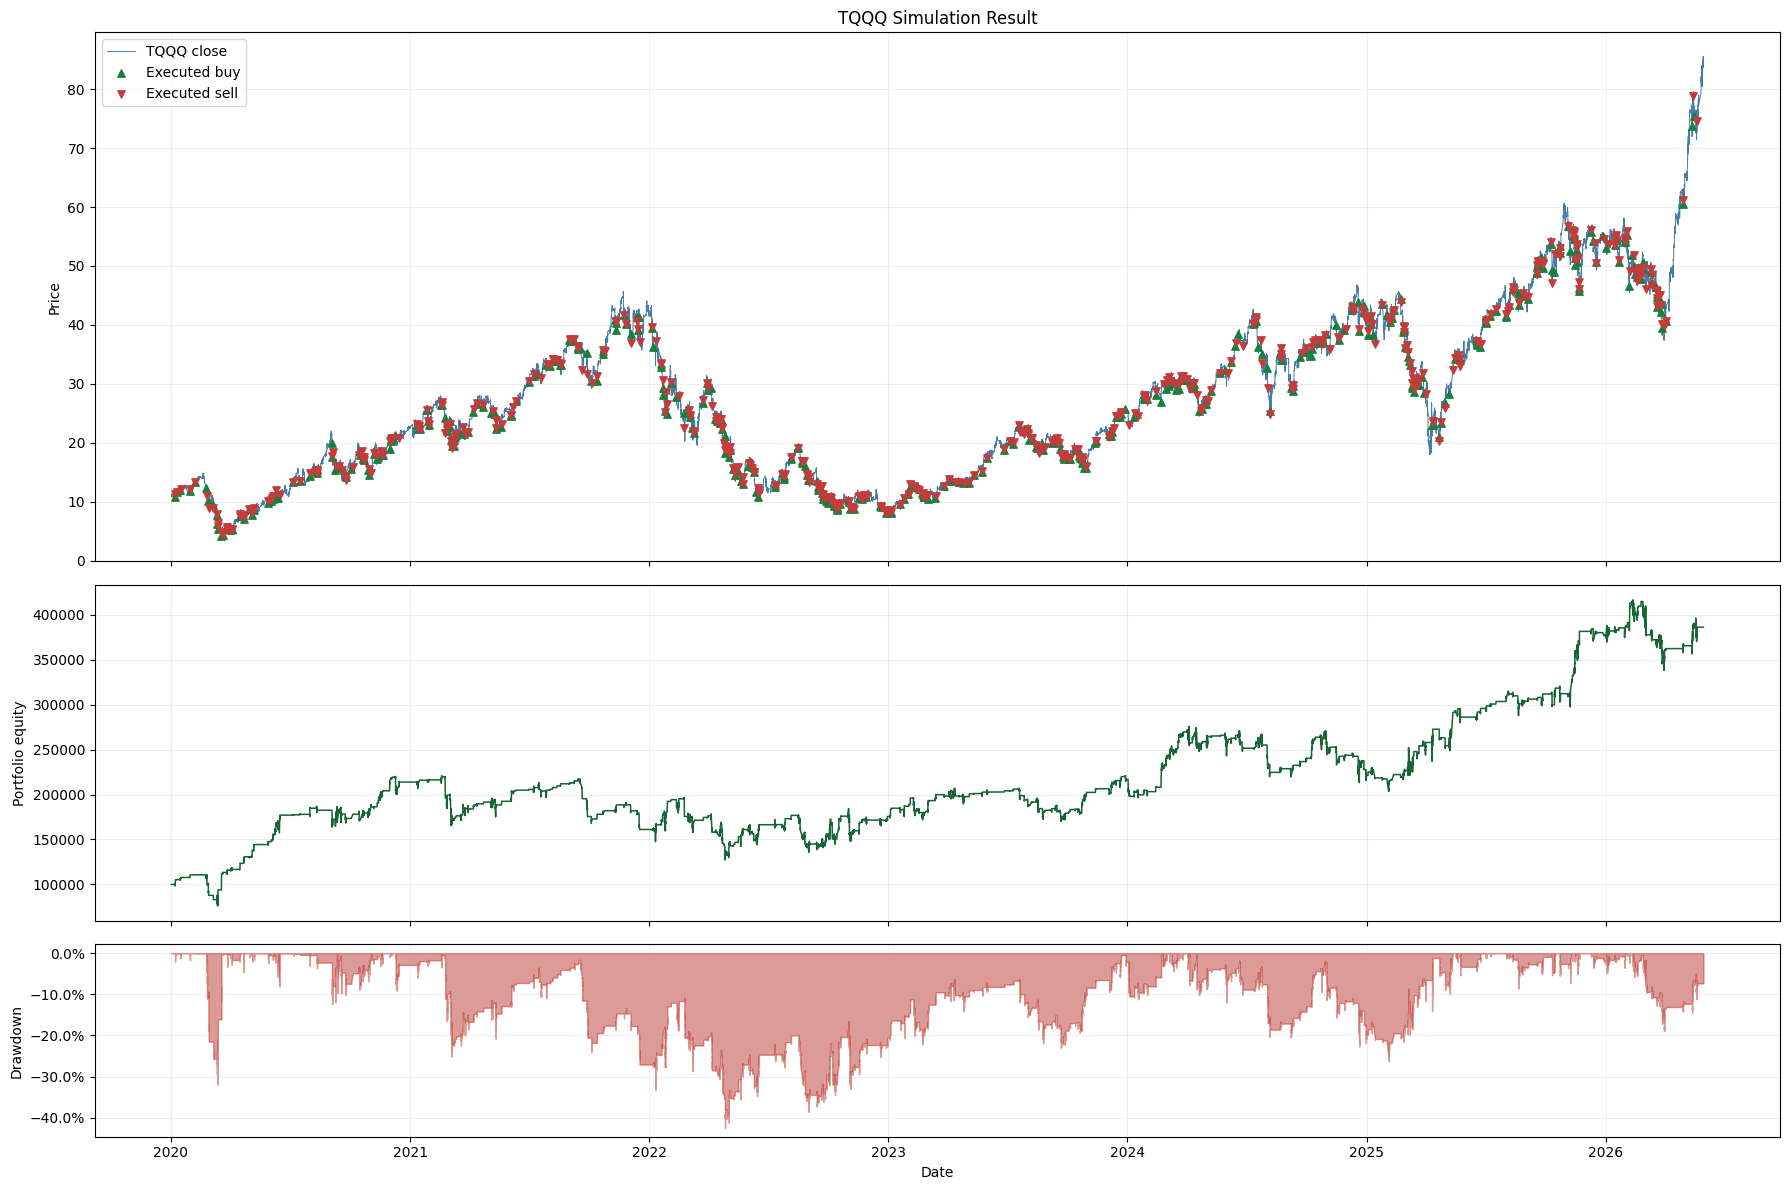

Saved plot: C:\Users\TonyTang\Documents\chan.py\outputs\TQQQ_simulation_result.png


In [14]:
from realistic_chan_simulation import (
    plot_simulation_result,
)

#output = run_realistic_simulation(config)

plot_path = plot_simulation_result(
    output,
    path="outputs/TQQQ_simulation_result.png",
    show=True,
)

print("Saved plot:", plot_path)